In [1]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split, KFold
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
from tensorflow import keras
from tensorflow.keras import layers
import cv2
import os
import numpy as np
import cv2
import os
dataset_path = r"C:\Users\PMLS\Desktop\images\imagesmodel\Train"
IMG_SIZE = (128, 128)
categories = ["Fake", "Real"]
data, labels = [], []
for category in categories:
    folder_path = os.path.join(dataset_path, category)
    label = categories.index(category)
    
    for img_name in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_name)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, IMG_SIZE)
        
        data.append(img)
        labels.append(label)

data = np.array(data, dtype=np.float32).reshape(-1, 128, 128, 1) / 255.0
labels = np.array(labels)
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.3, random_state=42)

In [2]:
pip install tensorflow


Note: you may need to restart the kernel to use updated packages.


In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import layers, Input, Model  # Correct Import


In [4]:
from sklearn.model_selection import train_test_split, KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)
accuracy_scores = []
from tensorflow import keras
from tensorflow.keras import layers

def CNN_Model():
    model = keras.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 1)),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu', kernel_regularizer=keras.regularizers.l2(0.0005)),  # L2 Regularization
        layers.Dropout(0.4),
        layers.Dense(len(categories), activation='softmax')
    ])
    return model  # Ensure model is returned

# Create and compile the model
model_cnn = CNN_Model()
model_cnn.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0005),
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])

model_cnn.summary()


C:\Users\PMLS\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 126, 126, 32)        │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       3,211,392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 2)                   │             258 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,304,322 (12.60 MB)

 Trainable params: 3,304,322 (12.60 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
callback = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history_cnn = model_cnn.fit(X_train, y_train, epochs=50, batch_size=64, validation_data=(X_test, y_test), callbacks=[callback])

Epoch 1/50
285/285 ━━━━━━━━━━━━━━━━━━━━ 90s 312ms/step - accuracy: 0.6505 - loss: 0.6647 - val_accuracy: 0.7812 - val_loss: 0.4969
Epoch 2/50
285/285 ━━━━━━━━━━━━━━━━━━━━ 86s 300ms/step - accuracy: 0.8005 - loss: 0.4687 - val_accuracy: 0.8518 - val_loss: 0.3758
Epoch 3/50
285/285 ━━━━━━━━━━━━━━━━━━━━ 86s 301ms/step - accuracy: 0.8614 - loss: 0.3602 - val_accuracy: 0.8768 - val_loss: 0.3259
Epoch 4/50
285/285 ━━━━━━━━━━━━━━━━━━━━ 88s 308ms/step - accuracy: 0.9043 - loss: 0.2826 - val_accuracy: 0.8997 - val_loss: 0.2882
Epoch 5/50
285/285 ━━━━━━━━━━━━━━━━━━━━ 84s 295ms/step - accuracy: 0.9250 - loss: 0.2414 - val_accuracy: 0.9088 - val_loss: 0.2639
Epoch 6/50
285/285 ━━━━━━━━━━━━━━━━━━━━ 83s 291ms/step - accuracy: 0.9345 - loss: 0.2192 - val_accuracy: 0.9126 - val_loss: 0.2654
Epoch 7/50
285/285 ━━━━━━━━━━━━━━━━━━━━ 147s 308ms/step - accuracy: 0.9380 - loss: 0.2149 - val_accuracy: 0.9087 - val_loss: 0.2725
Epoch 8/50
285/285 ━━━━━━━━━━━━━━━━━━━━ 83s 291ms/step - accuracy: 0.9509 - loss: 

In [6]:
from sklearn.metrics import classification_report, confusion_matrix


In [7]:
# Evaluate the model to get test accuracy
test_loss, test_acc = model_cnn.evaluate(X_test, y_test, verbose=0)

# Get predictions
y_pred = np.argmax(model_cnn.predict(X_test), axis=1)

# Compute precision, recall, f1-score
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')

# Print results
print(f"CNN Model Test Accuracy: {test_acc * 100:.2f}%")
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Save performance metrics to a file
with open("performance_metrics.txt", "w") as f:
    f.write(f"CNN Model Test Accuracy: {test_acc * 100:.2f}%\n")
    f.write(f"Precision: {precision:.2f}, Recall: {recall:.2f}, F1-Score: {f1:.2f}\n")
    f.write("Classification Report:\n" + classification_report(y_test, y_pred) + "\n")
    f.write("Confusion Matrix:\n" + str(confusion_matrix(y_test, y_pred)) + "\n")

244/244 ━━━━━━━━━━━━━━━━━━━━ 9s 37ms/step
CNN Model Test Accuracy: 92.12%
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.92      0.92      3908
           1       0.92      0.92      0.92      3892

    accuracy                           0.92      7800
   macro avg       0.92      0.92      0.92      7800
weighted avg       0.92      0.92      0.92      7800

Confusion Matrix:
 [[3614  294]
 [ 321 3571]]


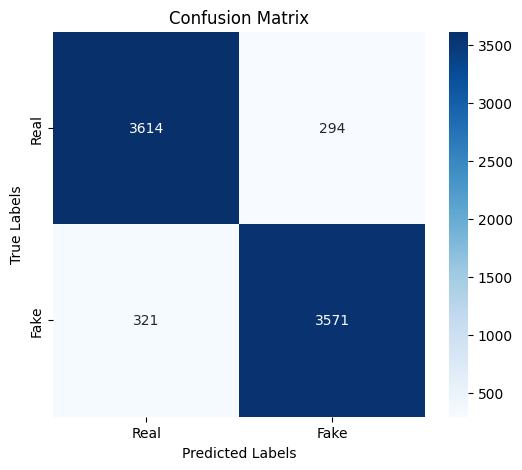

In [8]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)
classes = ['Real', 'Fake']

# Plot confusion matrix as heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()

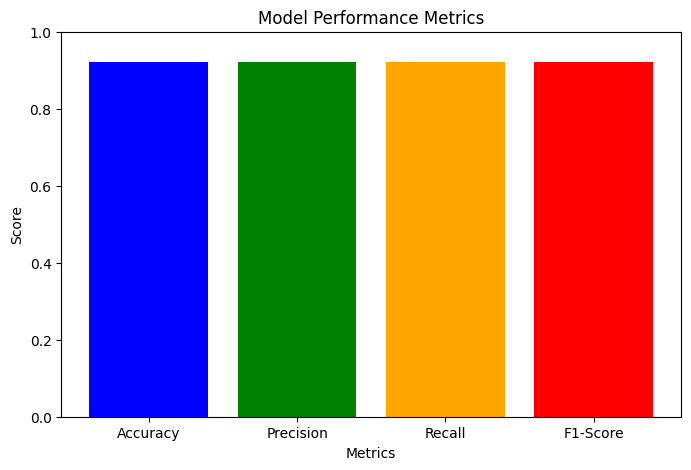

In [9]:
# Plot accuracy, precision, recall, and f1-score
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
values = [test_acc, precision, recall, f1]

plt.figure(figsize=(8, 5))
plt.bar(metrics, values, color=['blue', 'green', 'orange', 'red'])
plt.xlabel("Metrics")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.title("Model Performance Metrics")
plt.show()


In [10]:
import skimage.feature as sk


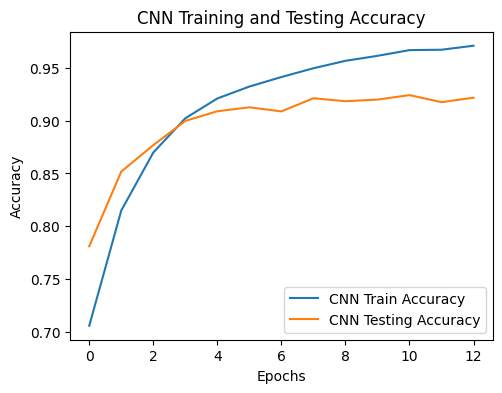

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_cnn.history['accuracy'], label='CNN Train Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='CNN Testing Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('CNN Training and Testing Accuracy')

plt.show()

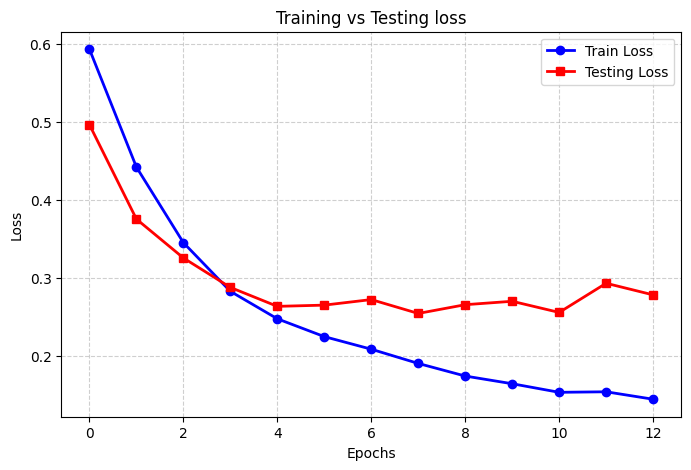

Mean Accuracy after k-Fold CV: nan%


C:\Users\PMLS\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\PMLS\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [13]:


import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 5))

# ✅ Loss Graph
plt.plot(history_cnn.history['loss'], color='blue', linestyle='-', linewidth=2, marker='o', label='Train Loss')
plt.plot(history_cnn.history['val_loss'], color='red', linestyle='-', linewidth=2, marker='s', label='Testing Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training vs Testing loss')

# ✅ Grid for better visualization
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

# ✅ Mean Accuracy from k-Fold Cross Validation
print(f"Mean Accuracy after k-Fold CV: {np.mean(accuracy_scores) * 100:.2f}%")



In [14]:
model_cnn.save("cnn_model.h5")
